In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
df = sns.load_dataset('titanic')

# Show the first 5 rows to see what we're working with
print("--- First 5 Rows ---")
print(df.head())

# Get a summary of the columns and missing values
print("\n--- Data Information ---")
print(df.info())

--- First 5 Rows ---
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  

--- Data Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       ------

In [2]:
# 1. Fill missing 'age' values with the average (median) age
df['age'] = df['age'].fillna(df['age'].median())

# 2. Fill missing 'embarked' (port of departure) with the most common port
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

# 3. Drop the 'deck' column because it has too many missing values to fix
df.drop(columns=['deck'], inplace=True)

# Check again to see if everything is clean
print(df.isnull().sum())

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    2
alive          0
alone          0
dtype: int64


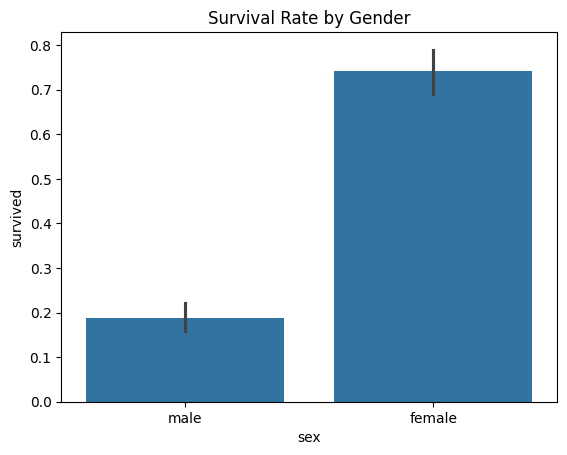

sex
female    0.742038
male      0.188908
Name: survived, dtype: float64


In [3]:
# Create a bar chart showing survival rate by Sex
sns.barplot(x='sex', y='survived', data=df)
plt.title('Survival Rate by Gender')
plt.show()

# This shows the exact percentage
print(df.groupby('sex')['survived'].mean())

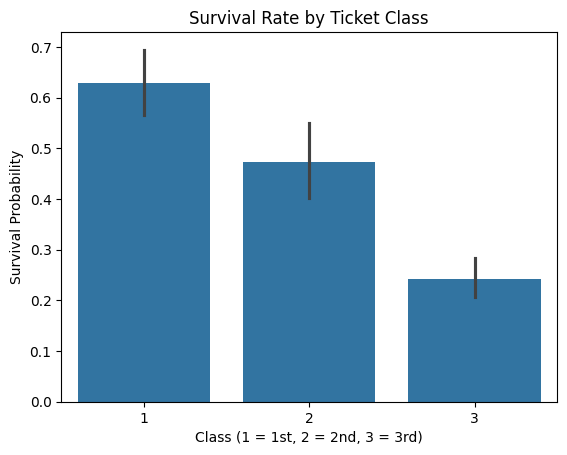

pclass
1    0.629630
2    0.472826
3    0.242363
Name: survived, dtype: float64


In [4]:
# Create a bar chart showing survival rate by Ticket Class
sns.barplot(x='pclass', y='survived', data=df)
plt.title('Survival Rate by Ticket Class')
plt.ylabel('Survival Probability')
plt.xlabel('Class (1 = 1st, 2 = 2nd, 3 = 3rd)')
plt.show()

# Calculate the exact percentages
print(df.groupby('pclass')['survived'].mean())

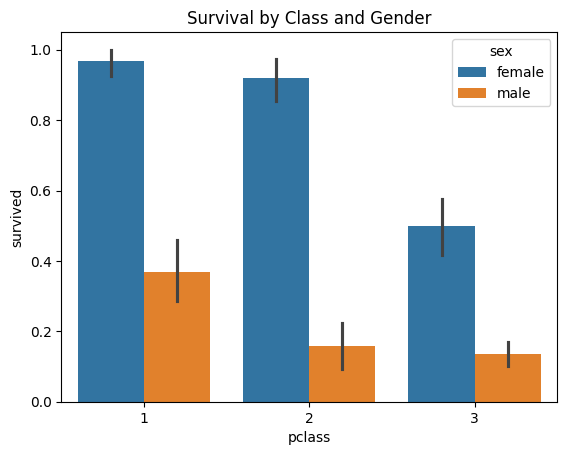

In [5]:
# A more advanced look: Survival by Class AND Gender
sns.barplot(x='pclass', y='survived', hue='sex', data=df)
plt.title('Survival by Class and Gender')
plt.show()